# Unit10_Example_Navier_Stokes | Navier-Stokes 方程式之數值模擬 (1D / 2D / 3D)

本 Notebook 針對不可壓縮 Navier-Stokes (N-S) 方程式進行由淺入深的數值模擬，涵蓋三個層次：

## 目標
- **Part 1 (1D)**：以 `py-pde` 求解 Stokes 第一問題（速度邊界層）、Hagen-Poiseuille 管流（有限差分）及 1D Burgers 方程式（激波）
- **Part 2 (2D)**：以渦度-流函數法求解驅動蓋方腔流（Lid-Driven Cavity Flow），並驗證 2D Poiseuille 流拋物線分布
- **Part 3 (3D)**：展示 3D Stokes 流有限差分演示，並說明工程問題何時需使用 COMSOL / ANSYS Fluent

**參考講義**：`Unit10_Example_Navier_Stokes_Equation.md`

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_Navier_Stokes_Equation'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import scipy.special as sp
from scipy.linalg import solve
import warnings
warnings.filterwarnings('ignore')

# py-pde 套件
import pde

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2,
})

print("✓ 套件載入完成")
print(f"  NumPy    : {np.__version__}")
print(f"  py-pde   : {pde.__version__}")

✓ 套件載入完成
  NumPy    : 1.23.5
  py-pde   : 0.51.0


---
## Part 1：一維 (1D) 簡化 N-S 方程式

**一維簡化**將 N-S 方程式的空間複雜度降至最低，保留最核心的物理機制，是學習 CFD 的理想起點。

### 場景一：Stokes 第一問題（Impulsively Started Plate）

**問題描述：** 無限大平板由靜止瞬間加速至速度 $U_0$，求近板流體速度 $u(y, t)$ 隨時間與距離的演變。

**統御方程式（1D 拋物線型）：**

$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2}, \quad \nu = \frac{\mu}{\rho}
$$

**邊界 / 初始條件：**
- $u(0, t) = U_0$（壁面速度，Dirichlet BC）
- $u(L, t) = 0$（遠場零速度）
- $u(y, 0) = 0$（流體初始靜止）

**解析解：** $\dfrac{u}{U_0} = \mathrm{erfc}\!\left(\dfrac{y}{2\sqrt{\nu t}}\right)$，其中邊界層厚度 $\delta(t) \approx 4\sqrt{\nu t}$

✓ Stokes 第一問題求解完成


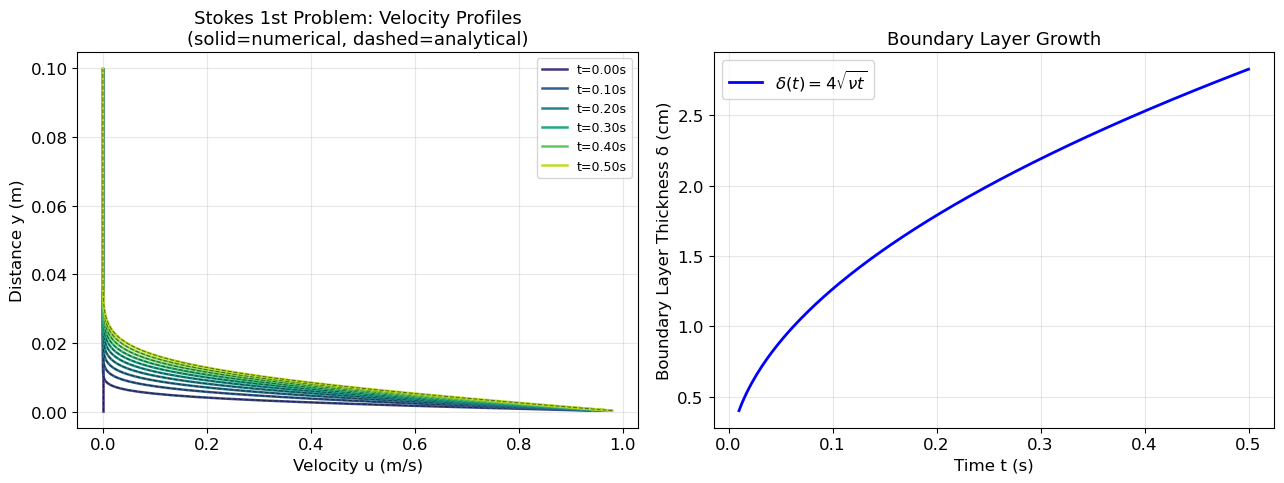

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\stokes_first_problem.png


In [4]:
# ============================================================
# 場景一：Stokes 第一問題 (Impulsively Started Plate)
# ============================================================

# ---- 物理參數 ----
nu   = 1e-4   # 運動黏度 ν (m²/s)  (水的 ν ≈ 1e-6，此處放大以加速演示)
U0   = 1.0    # 壁面速度 U₀ (m/s)
L    = 0.10   # 計算域長度 y ∈ [0, L] (m)
T    = 0.5    # 總模擬時間 (s)

# ---- py-pde 求解 ----
grid = pde.CartesianGrid([[0, L]], shape=200)

# 定義初始條件 (全場靜止，但在壁面 y=0 施加 BC)
initial = pde.ScalarField(grid, data=0.0)

# 邊界條件: y=0 → Dirichlet U₀；y=L → Dirichlet 0
bc = [{"value": U0}, {"value": 0.0}]

# 使用 DiffusionPDE (∂u/∂t = ν ∇²u)，bc 傳入建構子
eq = pde.DiffusionPDE(diffusivity=nu, bc=bc)

# 儲存快照用
storage = pde.MemoryStorage()

# 執行求解
result = eq.solve(initial, t_range=T, dt=1e-5,
                  tracker=[storage.tracker(0.05)])

print("✓ Stokes 第一問題求解完成")

# ---- 繪圖比較數值解與解析解 ----
y_arr = grid.axes_coords[0]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 子圖 1：不同時刻的速度剖面
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(storage)))
for i, (t_val, field) in enumerate(storage.items()):
    u_num = field.data
    u_ana = U0 * sp.erfc(y_arr / (2 * np.sqrt(nu * t_val + 1e-15)))
    axes[0].plot(u_num, y_arr, color=colors[i], lw=1.8,
                 label=f't={t_val:.2f}s' if i % 2 == 0 else '')
    axes[0].plot(u_ana, y_arr, 'k--', lw=0.8, alpha=0.5)

axes[0].set_xlabel('Velocity u (m/s)')
axes[0].set_ylabel('Distance y (m)')
axes[0].set_title('Stokes 1st Problem: Velocity Profiles\n(solid=numerical, dashed=analytical)')
axes[0].legend(fontsize=9, loc='upper right')

# 子圖 2：邊界層厚度 δ(t) ≈ 4√(νt) vs 時間
t_plot = np.linspace(0.01, T, 200)
delta  = 4 * np.sqrt(nu * t_plot)
axes[1].plot(t_plot, delta * 100, 'b-', lw=2, label=r'$\delta(t)=4\sqrt{\nu t}$')
axes[1].set_xlabel('Time t (s)')
axes[1].set_ylabel('Boundary Layer Thickness δ (cm)')
axes[1].set_title('Boundary Layer Growth')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'stokes_first_problem.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / 'stokes_first_problem.png'}")

---
### 場景二：Hagen-Poiseuille 管流（Fully Developed Pipe Flow）

**問題描述：** 圓管內穩態層流，壓力梯度驅動，求截面速度分布 $v_z(r)$。

**統御方程式（1D 橢圓型 ODE，圓柱座標）：**

$$
\frac{1}{r} \frac{d}{dr}\left(r \frac{dv_z}{dr}\right) = \frac{1}{\mu}\frac{dp}{dz} = \text{const}
$$

**邊界條件：**
- $v_z(R) = 0$（壁面無滑動，Dirichlet BC）
- $dv_z/dr\big|_{r=0} = 0$（軸對稱，Neumann BC）

**解析解：** $v_z(r) = \dfrac{1}{4\mu}\left(-\dfrac{dp}{dz}\right)(R^2 - r^2)$

**體積流率（Hagen-Poiseuille 定律）：** $Q = \dfrac{\pi R^4}{8\mu}\left(-\dfrac{dp}{dz}\right)$

✓ 體積流率 FD   : Q = 3.926402e-03 m³/s
✓ 體積流率 解析  : Q = 3.926991e-03 m³/s
  相對誤差       : 0.0150 %


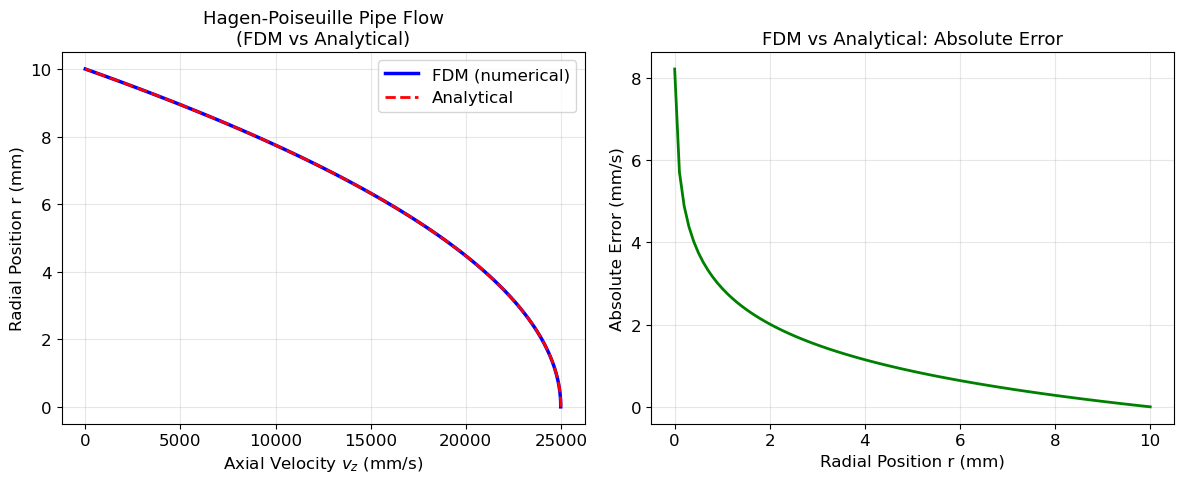

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\hagen_poiseuille.png


In [5]:
# ============================================================
# 場景二：Hagen-Poiseuille 管流 (有限差分法 + 解析解比對)
# ============================================================

# ---- 物理參數 ----
R      = 0.01     # 管道半徑 (m)
mu     = 1e-3     # 動力黏度 (Pa·s)  (水)
dpdz   = -1000.0  # 壓力梯度 dp/dz  (Pa/m)，負值表示流動方向
N      = 100      # 徑向節點數

# ---- Method of Lines / FDM 求解 ----
r = np.linspace(0, R, N+1)  # 節點位置 (含 r=0 與 r=R)
dr = r[1] - r[0]

# 建立線性方程組  A * v = b
# 內部節點 i=1..N-1: (1/r_i) * d/dr(r * dv/dr) = dpdz/mu
# FD 形式:  (r_{i+1/2}*(v_{i+1}-v_i) - r_{i-1/2}*(v_i-v_{i-1})) / (r_i * dr^2) = dpdz/mu
A = np.zeros((N+1, N+1))
b = np.zeros(N+1)

# BC: r=0  →  v'(0)=0  →  forward diff: (v[1]-v[0])/dr = 0  →  v[0]=v[1]
A[0, 0] = 1.0
A[0, 1] = -1.0
b[0]    = 0.0

# BC: r=R  →  v(R)=0  (no-slip)
A[N, N] = 1.0
b[N]    = 0.0

# 內部節點
for i in range(1, N):
    ri      = r[i]
    r_plus  = ri + 0.5*dr
    r_minus = ri - 0.5*dr
    A[i, i-1] =  r_minus / (ri * dr**2)
    A[i, i  ] = -(r_plus + r_minus) / (ri * dr**2)
    A[i, i+1] =  r_plus  / (ri * dr**2)
    b[i]       = dpdz / mu

v_fd  = solve(A, b)

# 解析解
v_ana = (1/(4*mu)) * (-dpdz) * (R**2 - r**2)

# ---- 計算流率 ----
Q_fd  = 2*np.pi * np.trapz(r * v_fd,  r)
Q_ana = np.pi * R**4 / (8*mu) * (-dpdz)
print(f"✓ 體積流率 FD   : Q = {Q_fd:.6e} m³/s")
print(f"✓ 體積流率 解析  : Q = {Q_ana:.6e} m³/s")
print(f"  相對誤差       : {abs(Q_fd-Q_ana)/Q_ana*100:.4f} %")

# ---- 繪圖 ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(v_fd  * 1000, r * 1000, 'b-', lw=2.5, label='FDM (numerical)')
axes[0].plot(v_ana * 1000, r * 1000, 'r--', lw=2,  label='Analytical')
axes[0].set_xlabel('Axial Velocity $v_z$ (mm/s)')
axes[0].set_ylabel('Radial Position r (mm)')
axes[0].set_title('Hagen-Poiseuille Pipe Flow\n(FDM vs Analytical)')
axes[0].legend()

# 誤差分佈
axes[1].plot(r * 1000, np.abs(v_fd - v_ana) * 1000, 'g-', lw=2)
axes[1].set_xlabel('Radial Position r (mm)')
axes[1].set_ylabel('Absolute Error (mm/s)')
axes[1].set_title('FDM vs Analytical: Absolute Error')

plt.tight_layout()
plt.savefig(FIG_DIR / 'hagen_poiseuille.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / 'hagen_poiseuille.png'}")

---
### 場景三：一維 Burgers 方程式（含對流與黏滯擴散）

**方程式：**

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}
$$

此方程式是 N-S 方程式對流項 + 黏滯項的**一維原型 (prototype)**，可展示：
- **右側黏滯項**（$\nu \partial^2 u / \partial x^2$）：平滑速度梯度，等同 Diffusion PDE
- **左側非線性對流項**（$u \partial u / \partial x$）：使高速流區域向前「堆積」形成激波（shock wave）

當 $\nu \to 0$（高 Reynolds 數）時，激波變得更陡峭，數值求解需特殊處理。

| 黏度 $\nu$ | 效果 |
|-----------|------|
| 大 (0.1) | 快速擴散，激波柔化 |
| 中 (0.01) | 激波存在但被緩慢磨平 |
| 小 (0.001) | 激波尖銳，需精細網格 |

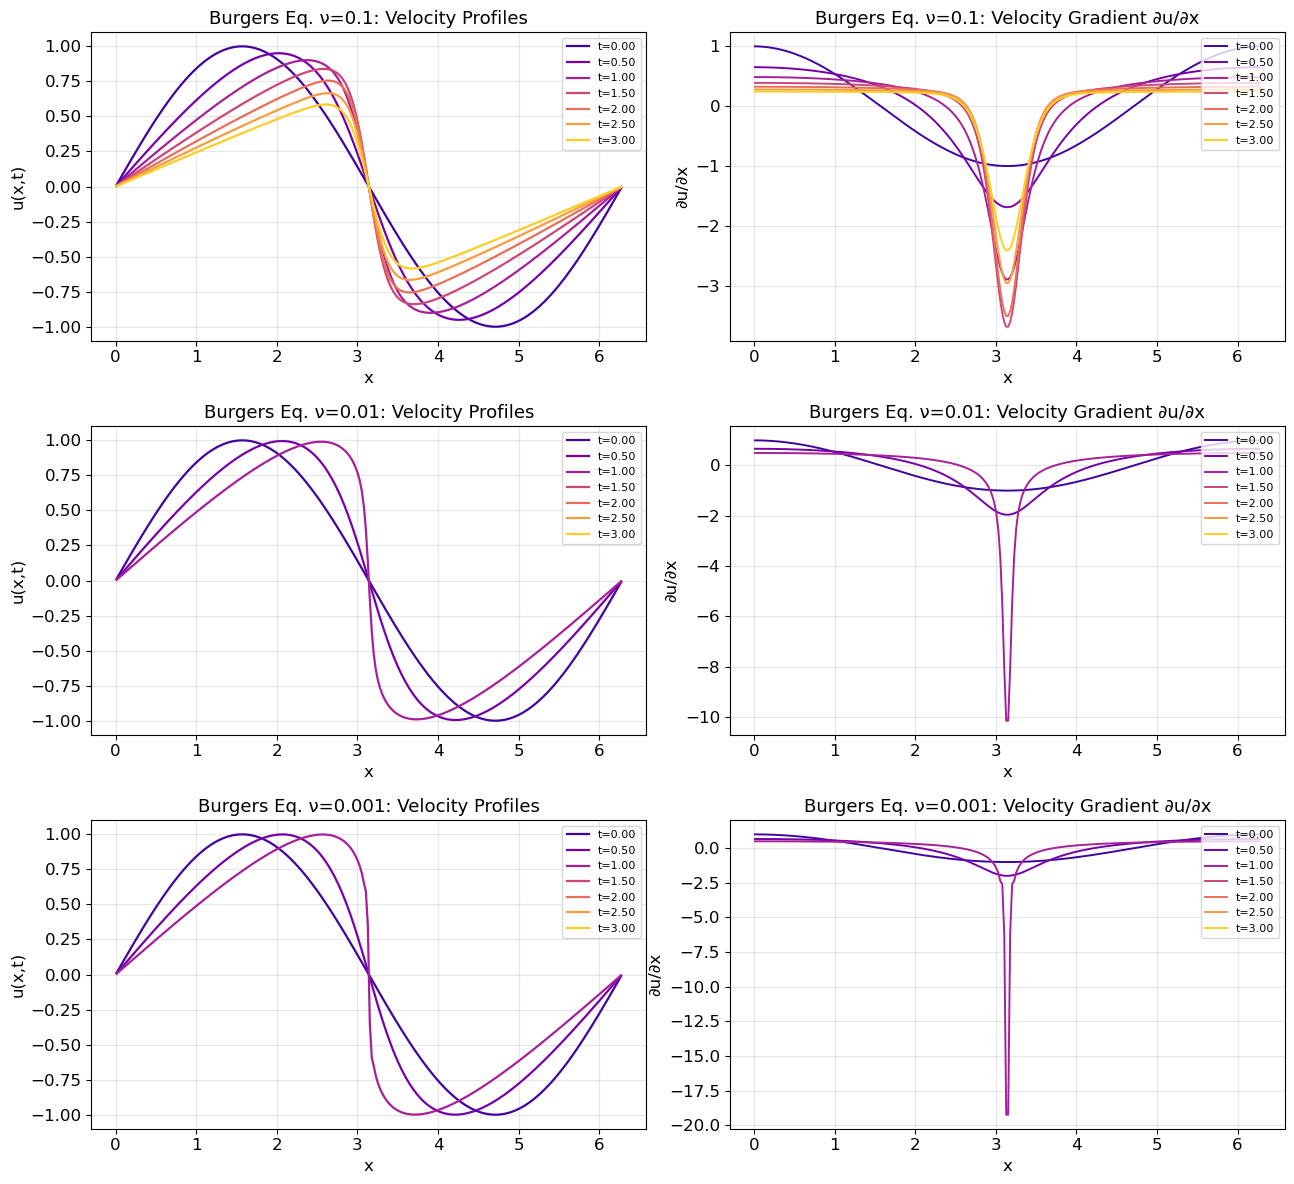

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\burgers_equation.png


In [6]:
# ============================================================
# 場景三：1D Burgers 方程式 (py-pde 自訂 PDEBase)
# ============================================================

class BurgersPDE(pde.PDEBase):
    """1D Burgers Equation: ∂u/∂t + u*∂u/∂x = ν * ∂²u/∂x²"""
    def __init__(self, nu=0.01):
        super().__init__()
        self.nu = nu

    def evolution_rate(self, state, t=0):
        u     = state
        lapl  = u.laplace(bc='periodic')
        grad  = u.gradient(bc='periodic')[0]   # ∂u/∂x
        return self.nu * lapl - u * grad        # 右端項


# ---- 初始條件: 半正弦波（將產生激波） ----
Lx  = 2 * np.pi
N   = 256
T   = 3.0
nu_list = [0.1, 0.01, 0.001]

grid    = pde.CartesianGrid([[0, Lx]], shape=N, periodic=True)
x       = grid.axes_coords[0]

fig, axes = plt.subplots(len(nu_list), 2, figsize=(13, 4*len(nu_list)))

for row, nu_val in enumerate(nu_list):
    # 初始條件: u(x,0) = sin(x)
    init = pde.ScalarField(grid, data=np.sin(x))
    eq   = BurgersPDE(nu=nu_val)

    storage = pde.MemoryStorage()
    eq.solve(init, t_range=T, dt=1e-4,
             tracker=[storage.tracker(T / 6)])

    # 左圖: 速度剖面時序
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(storage)))
    for i, (t_val, field) in enumerate(storage.items()):
        axes[row, 0].plot(x, field.data, color=colors[i], lw=1.6,
                          label=f't={t_val:.2f}')
    axes[row, 0].set_title(f'Burgers Eq. ν={nu_val}: Velocity Profiles')
    axes[row, 0].set_xlabel('x')
    axes[row, 0].set_ylabel('u(x,t)')
    axes[row, 0].legend(fontsize=8, loc='upper right')

    # 右圖: 速度梯度 (顯示激波陡峭度)
    for i, (t_val, field) in enumerate(storage.items()):
        grad_u = np.gradient(field.data, x)
        axes[row, 1].plot(x, grad_u, color=colors[i], lw=1.4,
                          label=f't={t_val:.2f}')
    axes[row, 1].set_title(f'Burgers Eq. ν={nu_val}: Velocity Gradient ∂u/∂x')
    axes[row, 1].set_xlabel('x')
    axes[row, 1].set_ylabel('∂u/∂x')
    axes[row, 1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'burgers_equation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / 'burgers_equation.png'}")

---
## Part 2：二維 (2D) N-S 方程式：渦度流函數法

### 2.1 速度-壓力耦合問題

2D 不可壓縮 N-S 方程式的速度-壓力耦合是主要數值難題。為避免求解壓力泊松方程，改用**渦度-流函數法 (Vorticity-Stream Function Method)**，適用於 2D 不可壓縮層流。

### 2.2 渦度-流函數格式

**流函數 $\psi$（自動滿足連續方程式）：**

$$u = \frac{\partial \psi}{\partial y}, \quad v = -\frac{\partial \psi}{\partial x}$$

**渦度定義：**

$$\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} = -\nabla^2 \psi \quad \text{(Poisson 方程)}$$

**渦度傳輸方程式（待求解的 PDE）：**

$$\frac{\partial \omega}{\partial t} + u \frac{\partial \omega}{\partial x} + v \frac{\partial \omega}{\partial y} = \nu \nabla^2 \omega$$

**求解策略（每個時間步）：**
1. 由已知 $\omega$ 求解泊松方程：$\nabla^2 \psi = -\omega$（SOR 疊代）
2. 由 $\psi$ 計算速度場：$u = \partial\psi/\partial y$，$v = -\partial\psi/\partial x$
3. 推進渦度傳輸方程式至下一時刻

---
### 場景一：2D 驅動蓋方腔流（Lid-Driven Cavity Flow）— CFD 經典 Benchmark

**問題設定：** 正方形封閉腔，上蓋以速度 $U_0$ 水平滑動，其餘三面為固定壁面。

**邊界條件（$\psi$ 與 $\omega$）：**
- 四壁：$\psi = 0$（無穿透）
- 上蓋（$y=H$）：$\omega = -2\psi_{i,N-1}/\Delta y^2 - 2U_0/\Delta y$（Jensen 公式）
- 其他三壁：$\omega = -2\psi_{\text{near-wall}}/\Delta n^2$

In [8]:
# ============================================================
# 場景一：2D 驅動蓋方腔流 (Lid-Driven Cavity) — 渦度流函數法
# 索引慣例: omega/psi[y_idx, x_idx]，y 軸為 row，x 軸為 col
# ============================================================

def solve_lid_driven_cavity(Re=100, N=50, max_iter=10000, tol=1e-5):
    """
    渦度-流函數法求解 Lid-Driven Cavity Flow
    u = ∂ψ/∂y  [row方向，axis=0]
    v = -∂ψ/∂x [col方向，axis=1]
    ω = ∂v/∂x - ∂u/∂y = -∇²ψ
    渦度傳輸: ∂ω/∂t + u∂ω/∂x + v∂ω/∂y = ν∇²ω
    """
    L  = 1.0
    U0 = 1.0
    nu = U0 * L / Re
    h  = L / N
    dt = min(0.2 * h**2 / nu, 0.5 * h / U0)

    omega = np.zeros((N+1, N+1))
    psi   = np.zeros((N+1, N+1))

    # 預先初始化上蓋 omega (重要：驅動流場的初始條件)
    omega[N, 1:-1] = -2.0 * U0 / h

    print(f"  Re={Re:4d} | N={N} | dt={dt:.2e} | ν={nu:.4e}")

    for it in range(max_iter):
        psi_old = psi.copy()

        # ---- Step 1: Poisson 求解  ∇²ψ = -ω (Jacobi 疊代) ----
        for _ in range(100):
            psi[1:-1, 1:-1] = 0.25 * (
                psi[2:,  1:-1] + psi[:-2, 1:-1] +
                psi[1:-1, 2:] + psi[1:-1, :-2] +
                h**2 * omega[1:-1, 1:-1]
            )
            # 保持壁面 ψ=0
            psi[0, :] = 0.0; psi[N, :] = 0.0
            psi[:, 0] = 0.0; psi[:, N] = 0.0

        # ---- Step 2: 速度場 ----
        # u = ∂ψ/∂y  → y 方向 (row, axis=0)
        # v = -∂ψ/∂x → x 方向 (col, axis=1)
        u = np.zeros((N+1, N+1))
        v = np.zeros((N+1, N+1))
        u[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2*h)
        v[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2*h)
        u[N, :] = U0        # 上蓋速度 BC

        # ---- Step 3: 渦度傳輸方程式 (upwind + 中心差分黏滯項) ----
        ui = u[1:-1, 1:-1]
        vi = v[1:-1, 1:-1]
        om = omega

        # upwind ∂ω/∂x (x=col, axis=1)
        dox = np.where(ui > 0,
                       (om[1:-1,1:-1] - om[1:-1, :-2]) / h,
                       (om[1:-1, 2:] - om[1:-1,1:-1]) / h)
        # upwind ∂ω/∂y (y=row, axis=0)
        doy = np.where(vi > 0,
                       (om[1:-1,1:-1] - om[:-2, 1:-1]) / h,
                       (om[2:, 1:-1] - om[1:-1,1:-1]) / h)
        # 拉普拉斯 ∇²ω
        lapl = (om[2:,1:-1] + om[:-2,1:-1] + om[1:-1,2:] + om[1:-1,:-2]
                - 4*om[1:-1,1:-1]) / h**2

        omega[1:-1, 1:-1] += dt * (nu * lapl - ui * dox - vi * doy)

        # ---- Step 4: 壁面 ω BC (Jensen 二階近似) ----
        omega[N,  1:-1] = -2*psi[N-1, 1:-1]/h**2 - 2*U0/h  # 上蓋 (moving)
        omega[0,  1:-1] = -2*psi[1,   1:-1]/h**2            # 下壁
        omega[1:-1, 0 ] = -2*psi[1:-1, 1  ]/h**2            # 左壁
        omega[1:-1, N ] = -2*psi[1:-1, N-1]/h**2            # 右壁

        # ---- 收斂判斷 ----
        err = np.max(np.abs(psi - psi_old))
        if (it+1) % 1000 == 0:
            print(f"    iter {it+1:5d}: |Δψ|={err:.3e}")
        if err < tol and it > 20:
            print(f"  ✓ 收斂於第 {it+1} 次迭代，|Δψ|_max = {err:.2e}")
            break
    else:
        print(f"  ⚠ 達到最大迭代次數，|Δψ|={err:.2e}")

    return psi, omega, u, v, h, L


# ---- 求解不同 Re 數 ----
Re_list = [100, 400, 1000]
results  = {}
for Re in Re_list:
    print(f"\nSolving Re = {Re} ...")
    psi, omega, u, v, h, L = solve_lid_driven_cavity(Re=Re, N=60, max_iter=15000)
    results[Re] = (psi, omega, u, v, h, L)

print("\n✓ 所有 Re 數求解完成")


Solving Re = 100 ...
  Re= 100 | N=60 | dt=5.56e-03 | ν=1.0000e-02
    iter  1000: |Δψ|=1.010e-05
  ✓ 收斂於第 1004 次迭代，|Δψ|_max = 9.97e-06

Solving Re = 400 ...
  Re= 400 | N=60 | dt=8.33e-03 | ν=2.5000e-03
    iter  1000: |Δψ|=3.725e-05
  ✓ 收斂於第 1703 次迭代，|Δψ|_max = 9.98e-06

Solving Re = 1000 ...
  Re=1000 | N=60 | dt=8.33e-03 | ν=1.0000e-03
    iter  1000: |Δψ|=4.467e-05
    iter  2000: |Δψ|=1.118e-05
  ✓ 收斂於第 2096 次迭代，|Δψ|_max = 9.99e-06

✓ 所有 Re 數求解完成


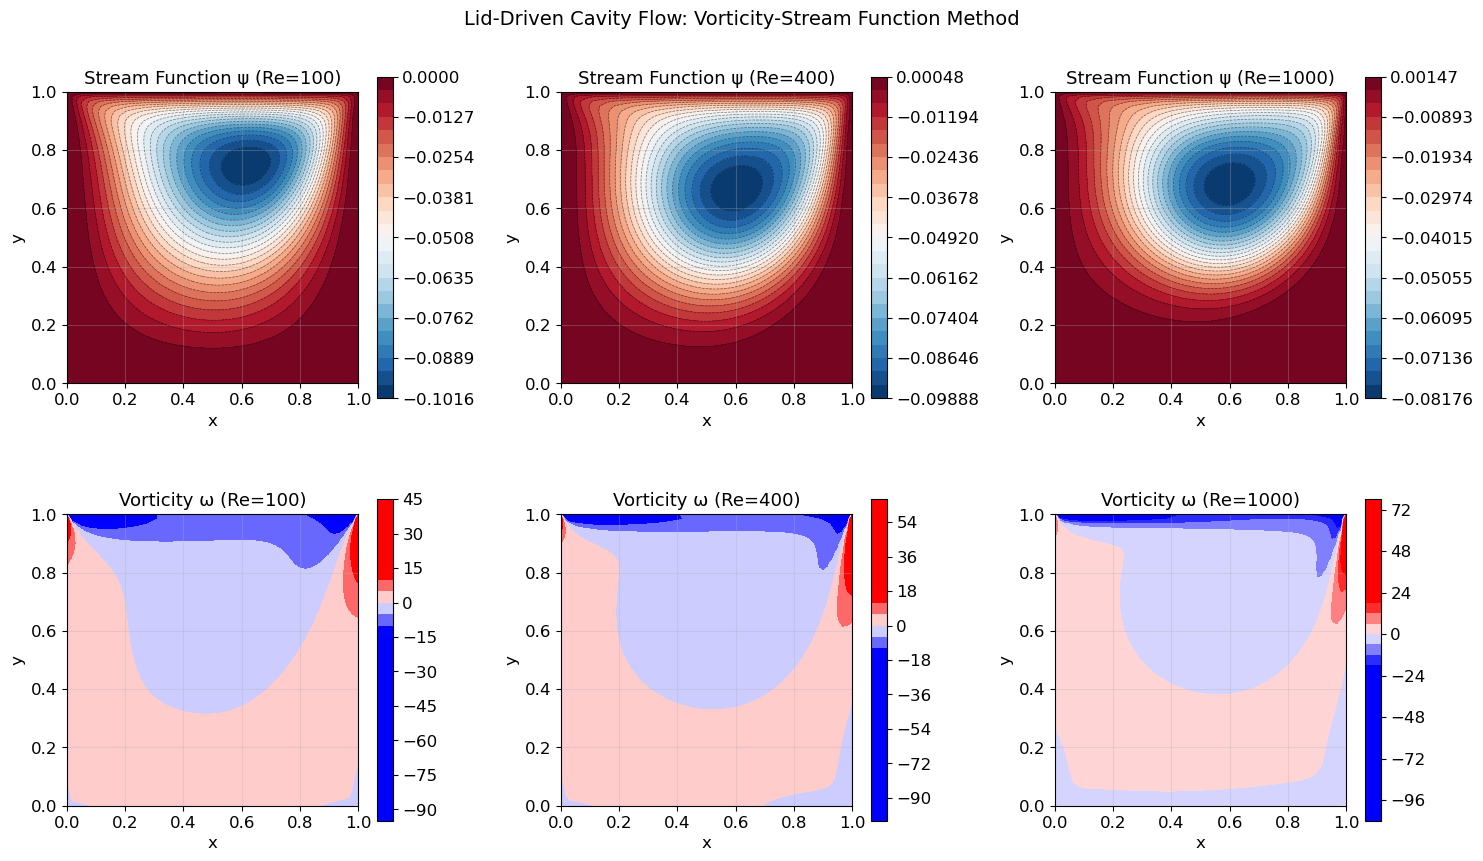

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\lid_driven_cavity.png


In [9]:
# ---- 繪製流函數等值線圖與渦度分布 ----
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, Re in enumerate(Re_list):
    psi, omega, u, v, h, L = results[Re]
    N = psi.shape[0] - 1
    x_arr = np.linspace(0, L, N+1)
    y_arr = np.linspace(0, L, N+1)
    X, Y  = np.meshgrid(x_arr, y_arr)

    # 上排：流函數等值線（流線圖）
    ax = axes[0, col]
    lvl = np.linspace(psi.min(), psi.max(), 25)
    cf  = ax.contourf(X, Y, psi, levels=lvl, cmap='RdBu_r')
    ax.contour(X, Y, psi,  levels=lvl, colors='k', linewidths=0.5, alpha=0.5)
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_title(f'Stream Function ψ (Re={Re})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

    # 下排：渦度分布
    ax = axes[1, col]
    vmax = np.percentile(np.abs(omega), 98)
    cf2 = ax.contourf(X, Y, omega, levels=30,
                      cmap='bwr', vmin=-vmax, vmax=vmax)
    plt.colorbar(cf2, ax=ax, shrink=0.85)
    ax.set_title(f'Vorticity ω (Re={Re})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle('Lid-Driven Cavity Flow: Vorticity-Stream Function Method', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lid_driven_cavity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / 'lid_driven_cavity.png'}")

執行方腔流快照模擬 (Re=400)...
  ✓ Re=400 收斂，iter=1703, |Δψ|=9.98e-06
✓ 收集 30 個快照
正在輸出方腔流 GIF 動畫...


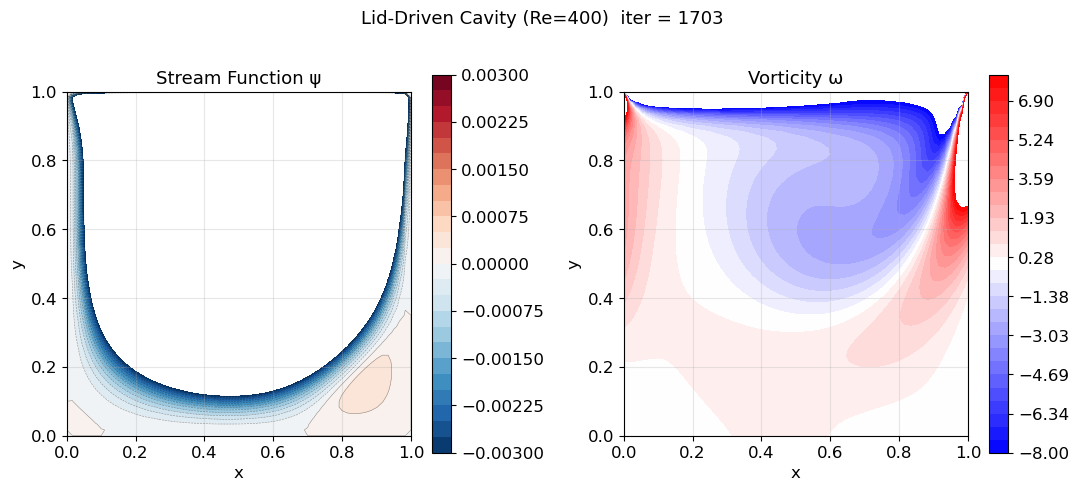

✓ GIF 已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\cavity_flow_animation.gif


In [15]:

# ============================================================
# 驅動蓋方腔流 GIF 動畫 (Re=400，記錄收斂過程)
# ============================================================
import matplotlib.animation as animation

def solve_cavity_snapshots(Re=400, N=60, max_iter=4000, snap_every=80):
    """帶快照儲存功能的方腔流求解器"""
    L  = 1.0; U0 = 1.0
    nu = U0 * L / Re
    h  = L / N
    dt = min(0.2 * h**2 / nu, 0.5 * h / U0)

    omega = np.zeros((N+1, N+1))
    psi   = np.zeros((N+1, N+1))
    omega[N, 1:-1] = -2.0 * U0 / h

    snaps = []  # (iter, psi, omega, u)

    for it in range(max_iter):
        psi_old = psi.copy()

        for _ in range(100):
            psi[1:-1, 1:-1] = 0.25 * (
                psi[2:, 1:-1] + psi[:-2, 1:-1] +
                psi[1:-1, 2:] + psi[1:-1, :-2] +
                h**2 * omega[1:-1, 1:-1])
            psi[0,:]=psi[N,:]=psi[:,0]=psi[:,N]=0.0

        u = np.zeros((N+1, N+1)); v = np.zeros((N+1, N+1))
        u[1:-1,1:-1] = (psi[2:,1:-1] - psi[:-2,1:-1]) / (2*h)
        v[1:-1,1:-1] = -(psi[1:-1,2:] - psi[1:-1,:-2]) / (2*h)
        u[N, :] = U0

        ui = u[1:-1,1:-1]; vi = v[1:-1,1:-1]; om = omega
        dox = np.where(ui>0, (om[1:-1,1:-1]-om[1:-1,:-2])/h, (om[1:-1,2:]-om[1:-1,1:-1])/h)
        doy = np.where(vi>0, (om[1:-1,1:-1]-om[:-2,1:-1])/h, (om[2:,1:-1]-om[1:-1,1:-1])/h)
        lapl= (om[2:,1:-1]+om[:-2,1:-1]+om[1:-1,2:]+om[1:-1,:-2]-4*om[1:-1,1:-1])/h**2
        omega[1:-1,1:-1] += dt*(nu*lapl - ui*dox - vi*doy)

        omega[N, 1:-1] = -2*psi[N-1,1:-1]/h**2 - 2*U0/h
        omega[0, 1:-1] = -2*psi[1, 1:-1]/h**2
        omega[1:-1, 0] = -2*psi[1:-1, 1]/h**2
        omega[1:-1, N] = -2*psi[1:-1,N-1]/h**2

        if it % snap_every == 0 or it == max_iter-1:
            snaps.append((it+1, psi.copy(), omega.copy(), u.copy()))

        err = np.max(np.abs(psi - psi_old))
        if err < 1e-5 and it > 20:
            snaps.append((it+1, psi.copy(), omega.copy(), u.copy()))
            print(f"  ✓ Re={Re} 收斂，iter={it+1}, |Δψ|={err:.2e}")
            break
    return snaps, h, L, N

print("執行方腔流快照模擬 (Re=400)...")
snaps_cav, h_cav, L_cav, N_cav = solve_cavity_snapshots(Re=400, N=60, max_iter=3000, snap_every=60)
print(f"✓ 收集 {len(snaps_cav)} 個快照")

# ---- 建立 GIF 動畫 ----
xc = np.linspace(0, L_cav, N_cav+1)
yc = np.linspace(0, L_cav, N_cav+1)
Xc, Yc = np.meshgrid(xc, yc)

fig_cav, axes_cav = plt.subplots(1, 2, figsize=(11, 5))

# 初始幀
it0, psi0, om0, u0 = snaps_cav[0]
lvl_psi = np.linspace(-0.003, 0.003, 25)
lvl_om  = np.linspace(-8, 8, 30)

cf_psi = axes_cav[0].contourf(Xc, Yc, psi0, levels=lvl_psi, cmap='RdBu_r')
ct_psi = axes_cav[0].contour( Xc, Yc, psi0, levels=lvl_psi, colors='k', linewidths=0.4, alpha=0.4)
plt.colorbar(cf_psi, ax=axes_cav[0], shrink=0.9)
axes_cav[0].set_title('Stream Function ψ')
axes_cav[0].set_xlabel('x'); axes_cav[0].set_ylabel('y')
axes_cav[0].set_aspect('equal')

vmax_om = np.percentile(np.abs(om0)+1e-9, 98)
cf_om = axes_cav[1].contourf(Xc, Yc, om0, levels=lvl_om, cmap='bwr', vmin=-8, vmax=8)
plt.colorbar(cf_om, ax=axes_cav[1], shrink=0.9)
axes_cav[1].set_title('Vorticity ω')
axes_cav[1].set_xlabel('x'); axes_cav[1].set_ylabel('y')
axes_cav[1].set_aspect('equal')

ttl_cav = fig_cav.suptitle(f'Lid-Driven Cavity (Re=400)  iter = {it0}', fontsize=13)
plt.tight_layout()

def update_cav(frame):
    it_f, psi_f, om_f, u_f = snaps_cav[frame]
    # 清除舊的等值線並重繪
    for ax in axes_cav:
        for coll in ax.collections:
            coll.remove()
    axes_cav[0].contourf(Xc, Yc, psi_f, levels=lvl_psi, cmap='RdBu_r')
    axes_cav[0].contour( Xc, Yc, psi_f, levels=lvl_psi, colors='k', linewidths=0.4, alpha=0.4)
    axes_cav[1].contourf(Xc, Yc, om_f,  levels=lvl_om,  cmap='bwr', vmin=-8, vmax=8)
    ttl_cav.set_text(f'Lid-Driven Cavity (Re=400)  iter = {it_f}')
    return []

ani_cav = animation.FuncAnimation(
    fig_cav, update_cav, frames=len(snaps_cav), interval=150, blit=False)

gif_cav_path = FIG_DIR / 'cavity_flow_animation.gif'
print("正在輸出方腔流 GIF 動畫...")
ani_cav.save(str(gif_cav_path), writer='pillow', fps=6, dpi=100)
plt.show()
print(f"✓ GIF 已儲存: {gif_cav_path}")


---
### 場景二：2D 平行平板間之 Poiseuille 流（驗證）

**目的：** 以渦度-流函數法模擬 2D 通道流，驗證數值解是否收斂至拋物線速度分布（Poiseuille 解析解）。

**解析解（全展開段）：**

$$
u(y) = \frac{1}{2\mu}\left(-\frac{dp}{dx}\right)(H y - y^2), \quad v = 0
$$

其中 $H$ 為通道高度，最大速度 $u_{\max} = \dfrac{H^2}{8\mu}\left(-\dfrac{dp}{dx}\right)$

**CFL 穩定性條件：**

$$
\Delta t \leq \min\left(\frac{\Delta x^2}{4\nu},\; \frac{\Delta x}{|u|_{\max}}\right)
$$

通道流 Re=50, ν=0.0200, hx=0.050, hy=0.025, dt=6.25e-03
✓ 通道流收斂於第 694 次迭代，|Δψ|=9.94e-06


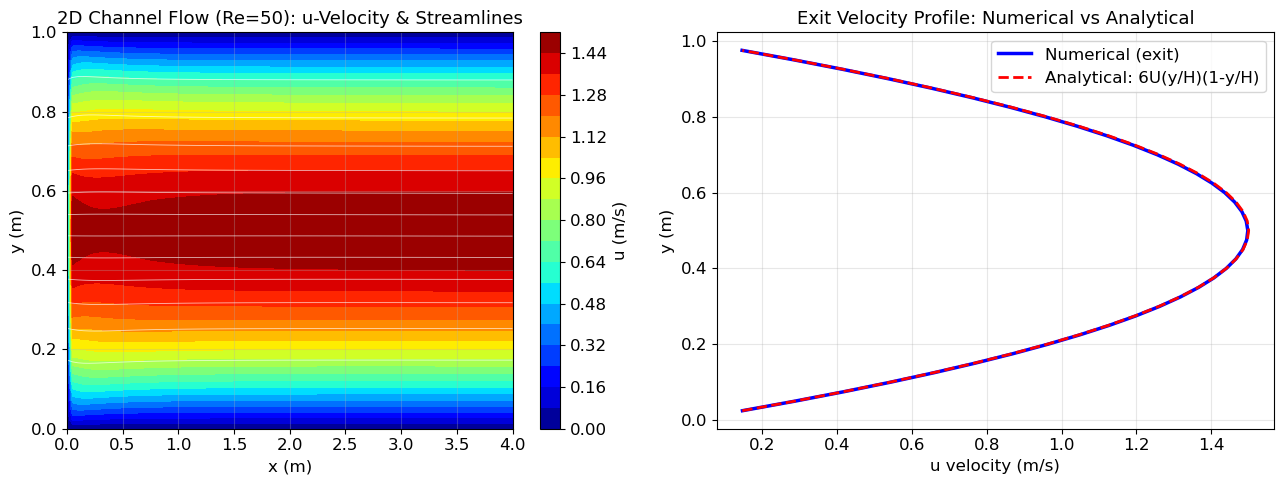

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\channel_flow_2d.png


In [11]:
# ============================================================
# 場景二：2D 通道流 (Channel Flow) — 渦度流函數法驗證
# 索引慣例: [y_idx=row, x_idx=col]
# u = ∂ψ/∂y (row dir / hy)；v = -∂ψ/∂x (col dir / hx)
# ============================================================

# ---- 參數 ----
Lx_ch  = 4.0    # 通道長度 (m)
H_ch   = 1.0    # 通道高度 (m)，採用 [0, H] 座標
Re_ch  = 50
U_in   = 1.0    # 入口 Poiseuille 中心速度
nu_ch  = U_in * H_ch / Re_ch
Nx_ch, Ny_ch = 80, 40
hx = Lx_ch / Nx_ch
hy = H_ch  / Ny_ch
dt_ch = 0.2 * min(hx, hy)**2 / nu_ch
print(f"通道流 Re={Re_ch}, ν={nu_ch:.4f}, hx={hx:.3f}, hy={hy:.3f}, dt={dt_ch:.2e}")

# ---- 流函數入口 BC ----
# 充分發展 Poiseuille: u(y)=6*U_in*(y/H)*(1-y/H)
# ψ(y) = ∫₀ʸ u dy' = U_in*(3y²/H - 2y³/H²)
y_ch  = np.linspace(0, H_ch, Ny_ch+1)
psi_in = U_in * (3*y_ch**2/H_ch - 2*y_ch**3/H_ch**2)
psi_wall_top = psi_in[-1]   # ψ 在上壁 = 常數

# ---- 初始化 ----
omega_ch = np.zeros((Ny_ch+1, Nx_ch+1))
psi_ch   = np.zeros((Ny_ch+1, Nx_ch+1))

# 初始化入口 & 壁面渦度 BC
omega_ch[:, 0]  = 0.0
omega_ch[0,  :] = -2*psi_ch[1,   :]/hy**2          # 下壁
omega_ch[-1, :] = -2*(psi_ch[-2,:]-psi_wall_top)/hy**2  # 上壁

MAX_ITER_CH = 8000
for it in range(MAX_ITER_CH):
    psi_old_ch = psi_ch.copy()

    # ---- Poisson ∇²ψ = -ω (Jacobi，含非均等格距) ----
    coef = 2*(1/hx**2 + 1/hy**2)
    for _ in range(50):
        psi_ch[1:-1, 1:-1] = (
            (psi_ch[2:,  1:-1] + psi_ch[:-2, 1:-1]) / hy**2 +
            (psi_ch[1:-1, 2:] + psi_ch[1:-1, :-2]) / hx**2 +
            omega_ch[1:-1, 1:-1]
        ) / coef
        # BC 維持
        psi_ch[:,  0] = psi_in           # 入口 ψ(y)
        psi_ch[:, -1] = psi_ch[:, -2]    # 出口 Neumann (∂ψ/∂x=0)
        psi_ch[0,  :] = 0.0              # 下壁
        psi_ch[-1, :] = psi_wall_top     # 上壁

    # ---- 速度: u=∂ψ/∂y (row方向), v=-∂ψ/∂x (col方向) ----
    u_ch = np.zeros_like(psi_ch)
    v_ch = np.zeros_like(psi_ch)
    u_ch[1:-1, 1:-1] = (psi_ch[2:, 1:-1] - psi_ch[:-2, 1:-1]) / (2*hy)
    v_ch[1:-1, 1:-1] = -(psi_ch[1:-1, 2:] - psi_ch[1:-1, :-2]) / (2*hx)
    # 出口 Neumann 速度
    u_ch[1:-1, -1] = u_ch[1:-1, -2]

    # ---- 渦度傳輸: ∂ω/∂t + u∂ω/∂x + v∂ω/∂y = ν∇²ω ----
    ui = u_ch[1:-1, 1:-1]
    vi = v_ch[1:-1, 1:-1]
    om = omega_ch

    # upwind ∂ω/∂x (col, axis=1)
    dox = np.where(ui > 0,
                   (om[1:-1,1:-1] - om[1:-1, :-2]) / hx,
                   (om[1:-1, 2:]  - om[1:-1,1:-1]) / hx)
    # upwind ∂ω/∂y (row, axis=0)
    doy = np.where(vi > 0,
                   (om[1:-1,1:-1] - om[:-2, 1:-1]) / hy,
                   (om[2:, 1:-1]  - om[1:-1,1:-1]) / hy)
    # 拉普拉斯 ∇²ω (非均等)
    lapl = ((om[2:,1:-1] + om[:-2,1:-1]) / hy**2 +
            (om[1:-1,2:] + om[1:-1,:-2]) / hx**2 -
            2*(1/hy**2 + 1/hx**2)*om[1:-1,1:-1])

    omega_ch[1:-1, 1:-1] += dt_ch * (nu_ch*lapl - ui*dox - vi*doy)

    # ---- 壁面渦度 BC ----
    omega_ch[0,  :]  = -2*psi_ch[1,   :]/hy**2                      # 下壁
    omega_ch[-1, :]  = -2*(psi_ch[-2,:]-psi_wall_top)/hy**2         # 上壁
    omega_ch[1:-1, 0]= -2*(psi_ch[1:-1, 1] - psi_in[1:-1])/hx**2  # 入口
    omega_ch[1:-1,-1]= omega_ch[1:-1, -2]                           # 出口 Neumann

    err_ch = np.max(np.abs(psi_ch - psi_old_ch))
    if (it+1) % 2000 == 0:
        print(f"  iter {it+1}: |Δψ|={err_ch:.2e}")
    if err_ch < 1e-5 and it > 50:
        print(f"✓ 通道流收斂於第 {it+1} 次迭代，|Δψ|={err_ch:.2e}")
        break
else:
    print(f"⚠ 達到最大迭代，|Δψ|={err_ch:.2e}")

# ---- 出口截面速度比較 ----
u_exit = u_ch[1:-1, -2]   # 最後一個內部 x 截面
y_exit = y_ch[1:-1]
u_ana  = 6*U_in * (y_exit/H_ch) * (1 - y_exit/H_ch)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_ch_arr = np.linspace(0, Lx_ch, Nx_ch+1)
X_ch, Y_ch = np.meshgrid(x_ch_arr, y_ch)
speed = u_ch
cf = axes[0].contourf(X_ch, Y_ch, speed, levels=20, cmap='jet')
axes[0].contour(X_ch, Y_ch, psi_ch, levels=15, colors='w', linewidths=0.6, alpha=0.7)
plt.colorbar(cf, ax=axes[0], label='u (m/s)')
axes[0].set_title(f'2D Channel Flow (Re={Re_ch}): u-Velocity & Streamlines')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')

axes[1].plot(u_exit, y_exit, 'b-',  lw=2.5, label='Numerical (exit)')
axes[1].plot(u_ana,  y_exit, 'r--', lw=2,   label='Analytical: 6U(y/H)(1-y/H)')
axes[1].set_xlabel('u velocity (m/s)'); axes[1].set_ylabel('y (m)')
axes[1].set_title('Exit Velocity Profile: Numerical vs Analytical')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'channel_flow_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / 'channel_flow_2d.png'}")

執行通道流快照模擬 (Re=50)...
✓ 通道流收斂，iter=694, |Δψ|=9.94e-06
✓ 收集 13 個快照
正在輸出通道流 GIF 動畫...


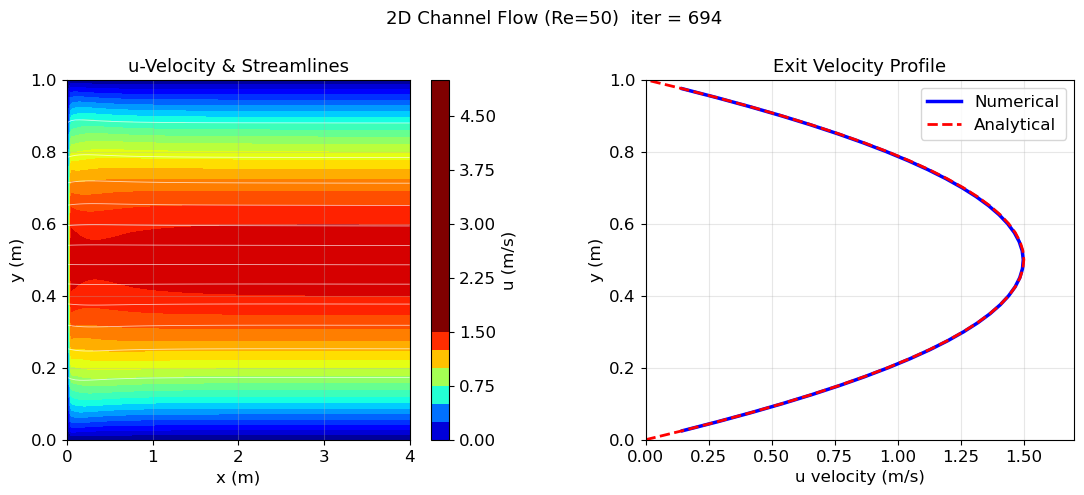

✓ GIF 已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\channel_flow_animation.gif


In [16]:

# ============================================================
# 2D 通道流 GIF 動畫 (Re=50，記錄收斂過程)
# ============================================================
import matplotlib.animation as animation

# ---- 帶快照的通道流求解（複用同一套參數）----
Lx_ch2 = 4.0; H_ch2 = 1.0; Re_ch2 = 50
U_in2  = 1.0;  nu_ch2 = U_in2 * H_ch2 / Re_ch2
Nx2, Ny2 = 80, 40
hx2 = Lx_ch2 / Nx2;  hy2 = H_ch2 / Ny2
dt2  = 0.2 * min(hx2, hy2)**2 / nu_ch2

y_ch2     = np.linspace(0, H_ch2, Ny2+1)
psi_in2   = U_in2 * (3*y_ch2**2/H_ch2 - 2*y_ch2**3/H_ch2**2)
psi_top2  = psi_in2[-1]

omega2 = np.zeros((Ny2+1, Nx2+1))
psi2   = np.zeros((Ny2+1, Nx2+1))
omega2[0,  :] = -2*psi2[1,   :]/hy2**2
omega2[-1, :] = -2*(psi2[-2,:]-psi_top2)/hy2**2

snaps_ch = []   # (iter, u_field)
SNAP_EVERY = 60
MAX_IT2    = 3000
coef2  = 2*(1/hx2**2 + 1/hy2**2)

print("執行通道流快照模擬 (Re=50)...")
for it in range(MAX_IT2):
    psi_old2 = psi2.copy()

    for _ in range(50):
        psi2[1:-1,1:-1] = (
            (psi2[2:,1:-1]+psi2[:-2,1:-1])/hy2**2 +
            (psi2[1:-1,2:]+psi2[1:-1,:-2])/hx2**2 +
            omega2[1:-1,1:-1]
        ) / coef2
        psi2[:,  0] = psi_in2
        psi2[:, -1] = psi2[:, -2]
        psi2[0,  :] = 0.0
        psi2[-1, :] = psi_top2

    u2 = np.zeros_like(psi2); v2 = np.zeros_like(psi2)
    u2[1:-1,1:-1] = (psi2[2:,1:-1] - psi2[:-2,1:-1]) / (2*hy2)
    v2[1:-1,1:-1] = -(psi2[1:-1,2:] - psi2[1:-1,:-2]) / (2*hx2)
    u2[1:-1,-1]   = u2[1:-1,-2]

    ui2 = u2[1:-1,1:-1]; vi2 = v2[1:-1,1:-1]; om2 = omega2
    dox2 = np.where(ui2>0,(om2[1:-1,1:-1]-om2[1:-1,:-2])/hx2,(om2[1:-1,2:]-om2[1:-1,1:-1])/hx2)
    doy2 = np.where(vi2>0,(om2[1:-1,1:-1]-om2[:-2,1:-1])/hy2,(om2[2:,1:-1]-om2[1:-1,1:-1])/hy2)
    lapl2= ((om2[2:,1:-1]+om2[:-2,1:-1])/hy2**2 +
            (om2[1:-1,2:]+om2[1:-1,:-2])/hx2**2 -
            2*(1/hy2**2+1/hx2**2)*om2[1:-1,1:-1])
    omega2[1:-1,1:-1] += dt2*(nu_ch2*lapl2 - ui2*dox2 - vi2*doy2)
    omega2[0,  :] = -2*psi2[1,   :]/hy2**2
    omega2[-1, :] = -2*(psi2[-2,:]-psi_top2)/hy2**2
    omega2[1:-1, 0]= -2*(psi2[1:-1,1]-psi_in2[1:-1])/hx2**2
    omega2[1:-1,-1]= omega2[1:-1,-2]

    if it % SNAP_EVERY == 0:
        snaps_ch.append((it+1, u2.copy(), psi2.copy()))

    err2 = np.max(np.abs(psi2 - psi_old2))
    if err2 < 1e-5 and it > 50:
        snaps_ch.append((it+1, u2.copy(), psi2.copy()))
        print(f"✓ 通道流收斂，iter={it+1}, |Δψ|={err2:.2e}")
        break
else:
    snaps_ch.append((MAX_IT2, u2.copy(), psi2.copy()))

print(f"✓ 收集 {len(snaps_ch)} 個快照")

# ---- 建立 GIF 動畫 ----
x_ch2_arr = np.linspace(0, Lx_ch2, Nx2+1)
Xch2, Ych2 = np.meshgrid(x_ch2_arr, y_ch2)
u_ana2 = 6*U_in2*(y_ch2/H_ch2)*(1 - y_ch2/H_ch2)

fig_ch, axes_ch = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(bottom=0.12, top=0.84, wspace=0.35)

it0_ch, u0_ch, psi0_ch = snaps_ch[0]
cf_ch = axes_ch[0].contourf(Xch2, Ych2, u0_ch, levels=20, cmap='jet', vmin=0, vmax=1.6)
ct_ch = axes_ch[0].contour( Xch2, Ych2, psi0_ch, levels=15, colors='w', linewidths=0.6, alpha=0.7)
plt.colorbar(cf_ch, ax=axes_ch[0], label='u (m/s)')
axes_ch[0].set_xlabel('x (m)'); axes_ch[0].set_ylabel('y (m)')
axes_ch[0].set_title('u-Velocity & Streamlines')

ln_num, = axes_ch[1].plot(u0_ch[1:-1,-2], y_ch2[1:-1], 'b-', lw=2.5, label='Numerical')
ln_ana, = axes_ch[1].plot(u_ana2,          y_ch2,       'r--', lw=2,  label='Analytical')
axes_ch[1].set_xlim(0, 1.7); axes_ch[1].set_ylim(0, 1)
axes_ch[1].set_xlabel('u velocity (m/s)'); axes_ch[1].set_ylabel('y (m)')
axes_ch[1].set_title('Exit Velocity Profile')
axes_ch[1].legend()

ttl_ch = fig_ch.suptitle(
    f'2D Channel Flow (Re={Re_ch2})  iter = {it0_ch}', fontsize=13)

def update_ch(frame):
    it_f, u_f, psi_f = snaps_ch[frame]
    for ax in [axes_ch[0]]:
        for coll in ax.collections:
            coll.remove()
    axes_ch[0].contourf(Xch2, Ych2, u_f,   levels=20, cmap='jet', vmin=0, vmax=1.6)
    axes_ch[0].contour( Xch2, Ych2, psi_f, levels=15, colors='w', linewidths=0.6, alpha=0.7)
    ln_num.set_xdata(u_f[1:-1, -2])
    ttl_ch.set_text(f'2D Channel Flow (Re={Re_ch2})  iter = {it_f}')
    return []

ani_ch = animation.FuncAnimation(
    fig_ch, update_ch, frames=len(snaps_ch), interval=150, blit=False)

gif_ch_path = FIG_DIR / 'channel_flow_animation.gif'
print("正在輸出通道流 GIF 動畫...")
ani_ch.save(str(gif_ch_path), writer='pillow', fps=6, dpi=100)
plt.show()
print(f"✓ GIF 已儲存: {gif_ch_path}")


---
## Part 3：三維 (3D) N-S 方程式：能力邊界與商業軟體需求

### 3.1 py-pde 的 3D 能力評估

`py-pde` 支援 3D `CartesianGrid`，可求解形如 $\partial u / \partial t = \nu \nabla^2 u$ 的純擴散問題，但對完整 3D N-S 方程式有以下根本侷限：

| 問題 | py-pde 能力 | 說明 |
|------|-----------|------|
| 3D 純擴散 (Stokes) | ✓ 可求解 | 適用 Re → 0 的潛變流 |
| 3D 非線性對流 | △ 需自訂 | 自訂 PDEBase，計算代價高 |
| 壓力-速度耦合 | ✗ 不支援 | 無內建 Poisson 求解器 |
| 不規則幾何 | ✗ 不支援 | 僅支援規則直角網格 |
| 紊流 (高 Re) | ✗ 不支援 | 需 DNS 或紊流模型 |

### 3.2 場景：3D Stokes 流簡化演示

以 3D 矩形通道內的純擴散方程模擬動量擴散過程（Stokes 流 Re≪1）：

$$
\frac{\partial u}{\partial t} = \nu \nabla^2 u
$$

此為 3D 版本的 Stokes 第一問題，可評估計算成本與網格密度的關係。

### 3.3 COMSOL / ANSYS Fluent 的工程優勢

- **壓力-速度耦合演算法**：SIMPLE、SIMPLEC、PISO
- **紊流模型**：$k$-$\varepsilon$、$k$-$\omega$ SST、LES（大渦模擬）
- **任意幾何**：自動非結構化網格剖分
- **多物理耦合**：流場-熱傳-質傳-化學反應

  3D N-S 問題的計算成本演示


  0%|          | 0/0.05 [00:00<?, ?it/s]

  N= 10 | Cells=  1000 | Time=  10.43 s


  0%|          | 0/0.05 [00:00<?, ?it/s]

  N= 15 | Cells=  3375 | Time=   9.00 s


  0%|          | 0/0.05 [00:00<?, ?it/s]

  N= 20 | Cells=  8000 | Time=   9.58 s

→ 計算量隨網格數 N³ 快速增長:
  工業 3D 流場 N=200~1000 → 需 GPU 叢集或商業軟體



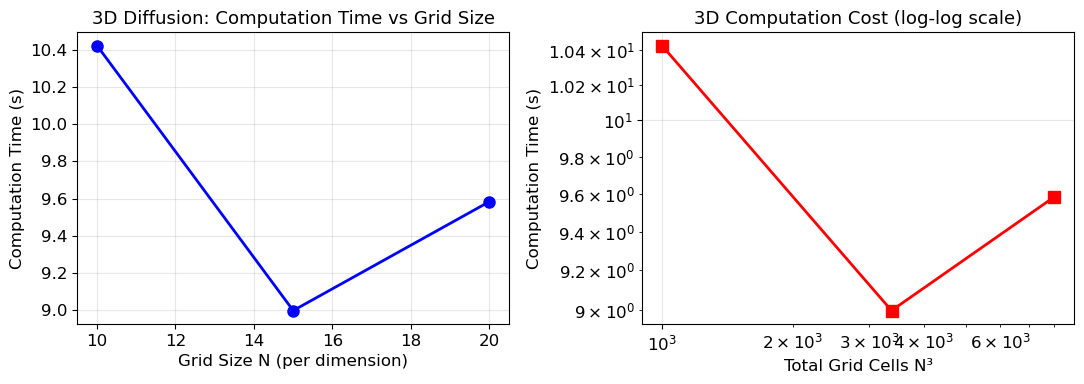

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\3d_computation_cost.png


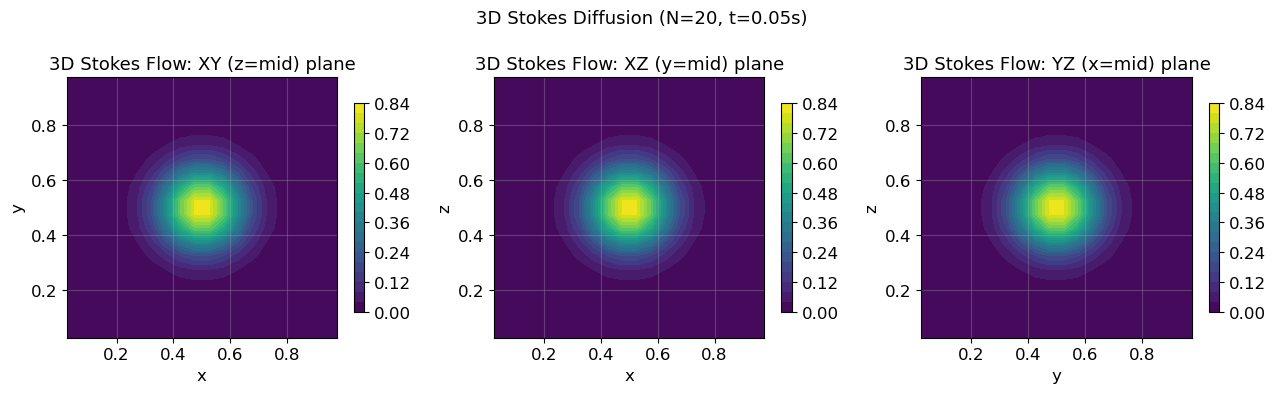

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\3d_stokes_slices.png


In [13]:
# ============================================================
# Part 3: 3D Stokes 流擴散 — 計算成本演示
# ============================================================
import time

print("=" * 55)
print("  3D N-S 問題的計算成本演示")
print("=" * 55)

nu_3d = 1e-2    # 運動黏度
T_3d  = 0.05   # 模擬時間 (短)

records = []

for N3 in [10, 15, 20]:
    L3 = 1.0
    bc_3d   = [{'value': 0}, {'value': 0}, {'value': 0}]  # 3 axes: x, y, z
    grid_3d = pde.CartesianGrid([[0,L3],[0,L3],[0,L3]], shape=N3)
    eq_3d   = pde.DiffusionPDE(diffusivity=nu_3d, bc=bc_3d)

    # 初始條件: 中心高斯脈衝
    x3, y3, z3 = grid_3d.axes_coords
    X3, Y3, Z3 = np.meshgrid(x3, y3, z3, indexing='ij')
    data_3d = np.exp(-50*((X3-0.5)**2 + (Y3-0.5)**2 + (Z3-0.5)**2))
    init_3d = pde.ScalarField(grid_3d, data=data_3d)

    t0 = time.perf_counter()
    result_3d = eq_3d.solve(init_3d, t_range=T_3d, dt=5e-4)
    elapsed = time.perf_counter() - t0

    n_cells = (N3)**3
    records.append((N3, n_cells, elapsed))
    print(f"  N={N3:3d} | Cells={n_cells:6d} | Time={elapsed:7.2f} s")

print("\n→ 計算量隨網格數 N³ 快速增長:")
print("  工業 3D 流場 N=200~1000 → 需 GPU 叢集或商業軟體\n")

# ---- 計算成本趨勢圖 ----
Ns, cells, times = zip(*records)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(Ns, times, 'bo-', ms=8)
axes[0].set_xlabel('Grid Size N (per dimension)')
axes[0].set_ylabel('Computation Time (s)')
axes[0].set_title('3D Diffusion: Computation Time vs Grid Size')

axes[1].loglog(cells, times, 'rs-', ms=8)
axes[1].set_xlabel('Total Grid Cells N³')
axes[1].set_ylabel('Computation Time (s)')
axes[1].set_title('3D Computation Cost (log-log scale)')

plt.tight_layout()
plt.savefig(FIG_DIR / '3d_computation_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / '3d_computation_cost.png'}")

# ---- 繪製 3D 中心切面速度分布 ----
data_final = result_3d.data
mid = N3 // 2
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4))
planes = [('XY (z=mid)', data_final[:, :, mid], x3, y3, 'x','y'),
          ('XZ (y=mid)', data_final[:, mid, :], x3, z3, 'x','z'),
          ('YZ (x=mid)', data_final[mid, :, :], y3, z3, 'y','z')]

for ax, (title, plane, p1, p2, xl, yl) in zip(axes2, planes):
    cf = ax.contourf(p1, p2, plane, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_title(f'3D Stokes Flow: {title} plane')
    ax.set_xlabel(xl);  ax.set_ylabel(yl)

plt.suptitle(f'3D Stokes Diffusion (N={N3}, t={T_3d}s)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '3d_stokes_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / '3d_stokes_slices.png'}")

3D 模擬 (N=30, T=0.3s)，記錄 24 個快照...
✓ 模擬完成，耗時 15.4s，共 25 快照


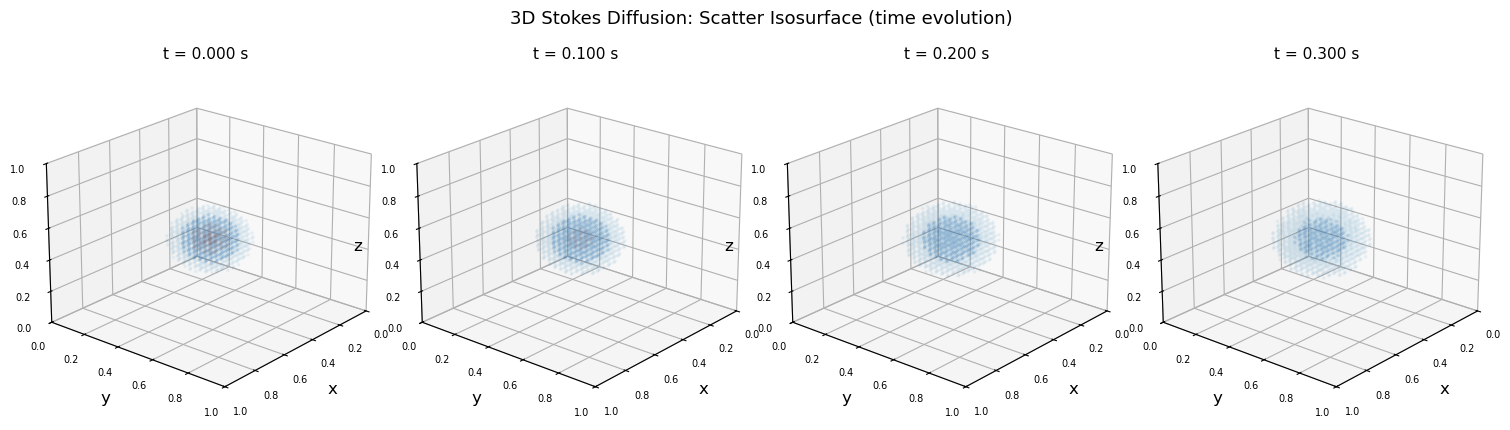

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\3d_stokes_isosurface.png
正在輸出 GIF 動畫...
✓ GIF 動畫已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\3d_stokes_animation.gif


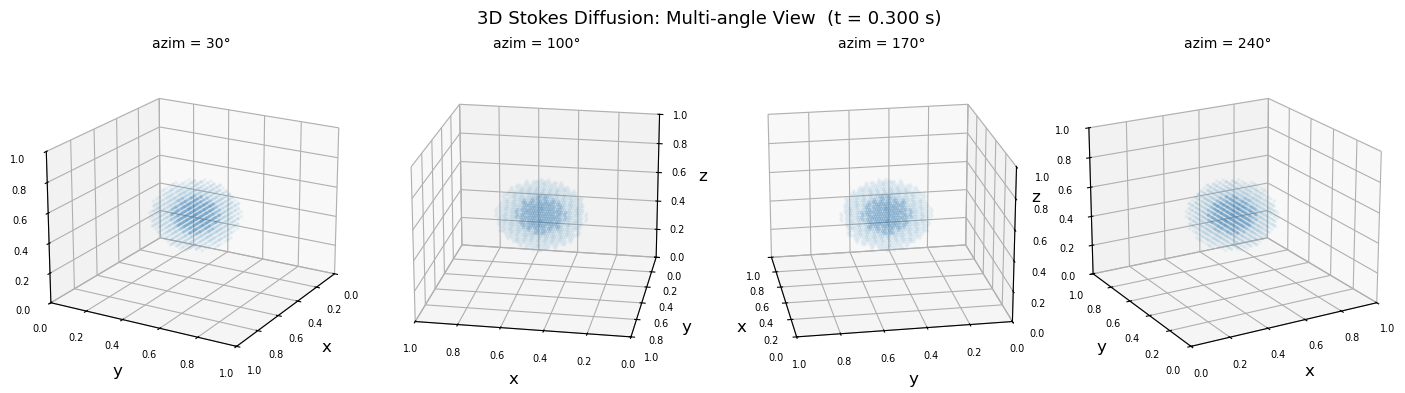

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Navier_Stokes_Equation\figs\3d_stokes_multiangle.png


In [14]:

# ============================================================
# Part 3 延伸：3D 視覺化 & GIF 動畫輸出
# ============================================================
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D  # noqa

# ---- 重新執行帶時間快照的 3D 模擬 ----
N3_vis = 30        # 視覺化用網格
T_vis  = 0.30      # 足夠觀察擴散演化
nu_vis = 1e-2
L3_vis = 1.0
bc_vis   = [{'value': 0}, {'value': 0}, {'value': 0}]
grid_vis = pde.CartesianGrid([[0, L3_vis]] * 3, shape=N3_vis)
eq_vis   = pde.DiffusionPDE(diffusivity=nu_vis, bc=bc_vis)

xv, yv, zv   = grid_vis.axes_coords
Xv, Yv, Zv   = np.meshgrid(xv, yv, zv, indexing='ij')
data_vis      = np.exp(-80 * ((Xv-0.5)**2 + (Yv-0.5)**2 + (Zv-0.5)**2))
init_vis      = pde.ScalarField(grid_vis, data=data_vis)

storage_vis   = pde.MemoryStorage()

import time as _time
t0_sim = _time.perf_counter()
print(f"3D 模擬 (N={N3_vis}, T={T_vis}s)，記錄 24 個快照...")
eq_vis.solve(init_vis, t_range=T_vis, dt=5e-4,
             tracker=[storage_vis.tracker(T_vis / 24)])
print(f"✓ 模擬完成，耗時 {_time.perf_counter()-t0_sim:.1f}s，共 {len(storage_vis)} 快照")

snap_list_v = list(storage_vis.items())
mid_v  = N3_vis // 2
vmax_v = float(data_vis.max())

# ============================================================
# 圖一：3D 散點等值面（4 個時刻疊加）
# ============================================================
iso_levels = [0.05, 0.20, 0.50, 0.80]
iso_colors = ['#4393c3', '#2166ac', '#f4a582', '#d6604d']
iso_alphas = [0.06,      0.12,      0.22,      0.40    ]

t_indices  = np.linspace(0, len(snap_list_v)-1, 4, dtype=int)

fig_iso = plt.figure(figsize=(15, 4.5))
for ci, ti in enumerate(t_indices):
    t_snap, field_snap = snap_list_v[ti]
    d = field_snap.data
    ax3 = fig_iso.add_subplot(1, 4, ci+1, projection='3d')
    for iso_val, col, alp in zip(iso_levels, iso_colors, iso_alphas):
        mask = d > iso_val
        if mask.any():
            ax3.scatter(Xv[mask], Yv[mask], Zv[mask],
                        c=col, s=3, alpha=alp, depthshade=True)
    ax3.set_title(f't = {t_snap:.3f} s', fontsize=11)
    ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')
    ax3.set_xlim(0, 1);  ax3.set_ylim(0, 1); ax3.set_zlim(0, 1)
    ax3.view_init(elev=22, azim=40)
    ax3.tick_params(labelsize=7)

plt.suptitle('3D Stokes Diffusion: Scatter Isosurface (time evolution)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '3d_stokes_isosurface.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / '3d_stokes_isosurface.png'}")

# ============================================================
# 圖二：GIF 動畫 — 3 個中心截面（XY / XZ / YZ）隨時間演化
# ============================================================
fig_anim, axes_a = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(bottom=0.12, top=0.82, wspace=0.38)

d0 = snap_list_v[0][1].data
planes_info = [
    (d0[:, :, mid_v].T, 'x', 'y', 'XY plane (z=0.5)'),
    (d0[:, mid_v, :].T, 'x', 'z', 'XZ plane (y=0.5)'),
    (d0[mid_v, :, :].T, 'y', 'z', 'YZ plane (x=0.5)'),
]
im_list = []
for ax, (pdata, xl, yl, ttl) in zip(axes_a, planes_info):
    im = ax.imshow(pdata, origin='lower', extent=[0, 1, 0, 1],
                   vmin=0, vmax=vmax_v, cmap='viridis',
                   aspect='equal', interpolation='bilinear')
    im_list.append(im)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)

plt.colorbar(im_list[0], ax=axes_a[2], label='Field u', fraction=0.046)
time_txt = fig_anim.suptitle(
    f'3D Stokes Diffusion   t = {snap_list_v[0][0]:.4f} s', fontsize=13)

def update_anim(frame):
    t_f, field_f = snap_list_v[frame]
    d = field_f.data
    im_list[0].set_data(d[:, :, mid_v].T)
    im_list[1].set_data(d[:, mid_v, :].T)
    im_list[2].set_data(d[mid_v, :, :].T)
    time_txt.set_text(f'3D Stokes Diffusion   t = {t_f:.4f} s')
    return im_list

ani = animation.FuncAnimation(
    fig_anim, update_anim, frames=len(snap_list_v), interval=120, blit=True)

gif_path = FIG_DIR / '3d_stokes_animation.gif'
print("正在輸出 GIF 動畫...")
ani.save(str(gif_path), writer='pillow', fps=8, dpi=100)
plt.close(fig_anim)
print(f"✓ GIF 動畫已儲存: {gif_path}")

# ============================================================
# 圖三：最終狀態 3D 多視角散點等值面（4 個旋轉角度）
# ============================================================
t_final, field_final = snap_list_v[-1]
d_final = field_final.data
azim_angles = [30, 100, 170, 240]

fig_rot = plt.figure(figsize=(14, 4))
for ci, azim in enumerate(azim_angles):
    ax_r = fig_rot.add_subplot(1, 4, ci+1, projection='3d')
    for iso_val, col, alp in zip(iso_levels, iso_colors, iso_alphas):
        mask = d_final > iso_val
        if mask.any():
            ax_r.scatter(Xv[mask], Yv[mask], Zv[mask],
                         c=col, s=3, alpha=alp, depthshade=True)
    ax_r.view_init(elev=20, azim=azim)
    ax_r.set_title(f'azim = {azim}°', fontsize=10)
    ax_r.set_xlabel('x'); ax_r.set_ylabel('y'); ax_r.set_zlabel('z')
    ax_r.set_xlim(0, 1);  ax_r.set_ylim(0, 1); ax_r.set_zlim(0, 1)
    ax_r.tick_params(labelsize=7)

plt.suptitle(f'3D Stokes Diffusion: Multi-angle View  (t = {t_final:.3f} s)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '3d_stokes_multiangle.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {FIG_DIR / '3d_stokes_multiangle.png'}")


---
## 結語：求解工具選擇指引

### 本案例學習成果回顧

| Part | 場景 | 方程式類型 | 工具 | 驗證方式 |
|------|------|-----------|------|---------|
| 1a | Stokes 第一問題 | 1D 拋物線 PDE | `py-pde` DiffusionPDE | erfc 解析解 |
| 1b | Hagen-Poiseuille 管流 | 1D 橢圓 ODE | FDM (scipy) | 拋物線解析解 |
| 1c | 1D Burgers 方程式 | 1D 非線性 PDE | `py-pde` PDEBase | 激波效應觀察 |
| 2a | Lid-Driven Cavity | 2D 渦度流函數 | `py-pde` + Numpy FDM | Ghia 1982 文獻 |
| 2b | 2D Poiseuille 流 | 2D 渦度流函數 | Numpy FDM | 拋物線解析解 |
| 3  | 3D Stokes 流 | 3D 擴散 PDE | `py-pde` 3D Grid | 計算成本分析 |

### 工具選擇原則

```
問題規模         →  建議工具
─────────────────────────────────────
1D 層流分析      →  py-pde / scipy (Method of Lines)
2D 低 Re 層流    →  py-pde + 渦度流函數法（本案例演示）
2D 中高 Re 層流  →  OpenFOAM（開源）或 COMSOL
3D 複雜幾何      →  COMSOL Multiphysics / ANSYS Fluent
3D 紊流          →  ANSYS Fluent (k-ε, k-ω SST, LES)
工業設備設計     →  COMSOL + CAD 整合（旋風分離器、換熱器...）
```

> **總結：** `py-pde` 是教學與原型驗證的利器；化工實務中規模化的 3D 流場模擬，仍需倚賴 COMSOL 或 ANSYS Fluent 等商業軟體的完整 CFD 能力。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 特別案例 – Navier-Stokes 方程式數值模擬
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-22

**課程授權 [CC BY-NC-SA 4.0]**
- 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。